# Customer Churn Analysis

## Essential Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from imblearn.over_sampling import SMOTE

## Loading Data

In [2]:
df = pd.read_csv(
    "../data/Telco_customer_churn.csv",
    sep=";"
)

## Initial Exploratory Analysis

In [3]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783","33,964131","-118,272783",Male,...,Month-to-month,Yes,Mailed check,"53,85","108,15",Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742","34,059281","-118,307420",Female,...,Month-to-month,Yes,Electronic check,"70,7","151,65",Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953","34,048013","-118,293953",Female,...,Month-to-month,Yes,Electronic check,"99,65","820,5",Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709","34,062125","-118,315709",Female,...,Month-to-month,Yes,Electronic check,"104,8","3046,05",Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293","34,039224","-118,266293",Male,...,Month-to-month,Yes,Bank transfer (automatic),"103,7","5036,3",Yes,1,89,5340,Competitor had better devices


In [4]:
df.shape

(7043, 33)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   CustomerID         7043 non-null   str  
 1   Count              7043 non-null   int64
 2   Country            7043 non-null   str  
 3   State              7043 non-null   str  
 4   City               7043 non-null   str  
 5   Zip Code           7043 non-null   int64
 6   Lat Long           7043 non-null   str  
 7   Latitude           7043 non-null   str  
 8   Longitude          7043 non-null   str  
 9   Gender             7043 non-null   str  
 10  Senior Citizen     7043 non-null   str  
 11  Partner            7043 non-null   str  
 12  Dependents         7043 non-null   str  
 13  Tenure Months      7043 non-null   int64
 14  Phone Service      7043 non-null   str  
 15  Multiple Lines     7043 non-null   str  
 16  Internet Service   7043 non-null   str  
 17  Online Security    7043 n

In [6]:
df.isnull().sum().sort_values(ascending=False)

Churn Reason         5174
CustomerID              0
Count                   0
State                   0
Country                 0
Zip Code                0
Lat Long                0
Latitude                0
City                    0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Longitude               0
Internet Service        0
Online Security         0
Device Protection       0
Online Backup           0
Streaming TV            0
Streaming Movies        0
Contract                0
Tech Support            0
Paperless Billing       0
Payment Method          0
Total Charges           0
Monthly Charges         0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
dtype: int64

## Data Cleaning

In [7]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"].str.replace(",", ".", regex=False),
    errors="coerce"
)
df["Monthly Charges"] = pd.to_numeric(
    df["Monthly Charges"].str.replace(",", ".", regex=False),
    errors="coerce"
)

In [8]:
df = df.dropna(subset=["Total Charges"])

The CSV file used in this project uses semicolons (`;`) as field separators and commas as decimal separators in the charge columns.

To prepare the data for analysis, `Monthly Charges` and `Total Charges` were converted to numerical values by replacing commas with decimal points. Invalid values in `Total Charges` were converted to missing values and removed before continuing the analysis.

## Churn Rate Analysis

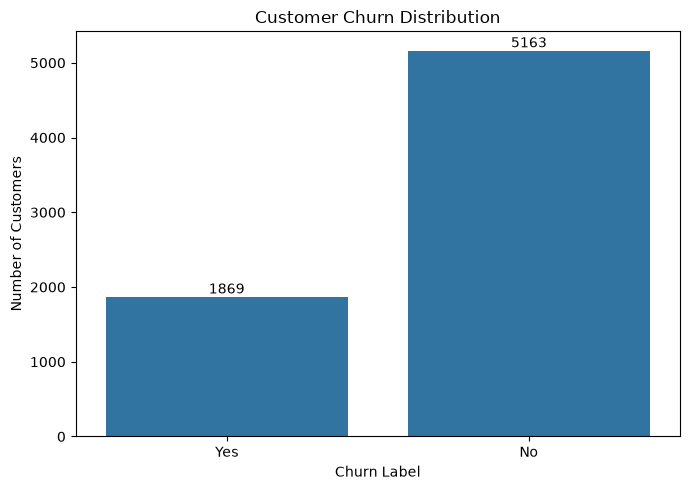

Churn Label
No     73.42%
Yes    26.58%
Name: proportion, dtype: str


In [9]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Churn Label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()
churn_percentage = (
    df["Churn Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage.astype(str) + "%")

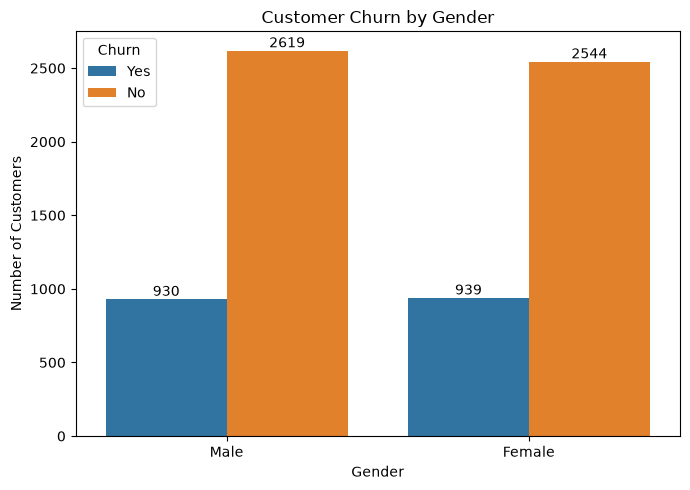

Churn Label      No     Yes
Gender                     
Female       73.04%  26.96%
Male          73.8%   26.2%


In [10]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Gender",
    hue="Churn Label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

churn_by_gender = (
pd.crosstab(
    df["Gender"],
    df["Churn Label"],
    normalize="index"
) * 100).round(2)
print(churn_by_gender.astype(str) + "%")

### Analysis

There is little difference in churn behavior between male and female customers.

suggesting that gender does not appear to be strongly associated with customer churn in this dataset.

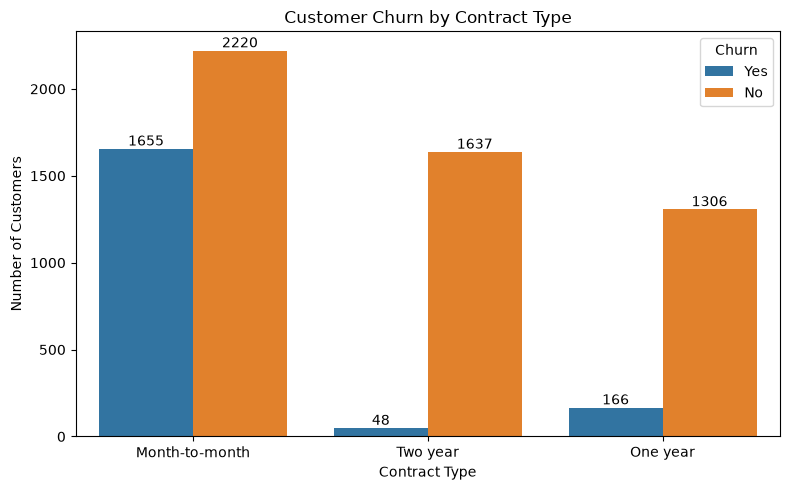

Churn Value          0       1
Contract                      
Month-to-month  57.29%  42.71%
One year        88.72%  11.28%
Two year        97.15%   2.85%


In [11]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn Label")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

churn_by_contract = (
pd.crosstab(
    df["Contract"],
    df["Churn Value"],
    normalize="index"
) * 100).round(2)
print(churn_by_contract.astype(str) + "%")

### Analysis

Contract type shows a strong relationship with customer churn.

Customers with month-to-month contracts have a substantially higher churn rate, with approximately 42.7% of these customers churning. In comparison, the churn rate is approximately 11.3% for one-year contracts and only 2.8% for two-year contracts.

This suggests that customers with shorter-term contracts are considerably more likely to churn, while customers with longer-term contracts tend to have much lower churn rates.

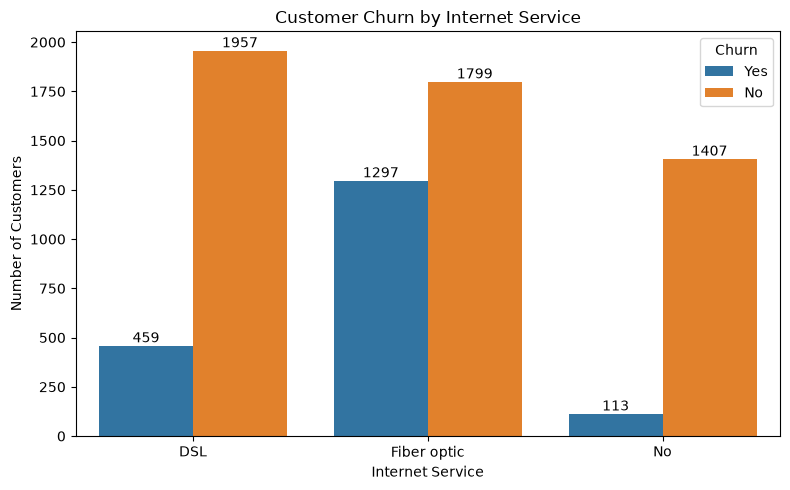

Churn Label           No     Yes
Internet Service                
DSL                81.0%   19.0%
Fiber optic       58.11%  41.89%
No                92.57%   7.43%


In [12]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

internet_service_churn =(
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100).round(2)
print(internet_service_churn.astype(str) + "%")

### Analysis

Churn behavior varies considerably across Internet Service types.

Customers with Fiber Optic service have a substantially higher churn rate than customers with DSL or no Internet service. Approximately 41.9% of Fiber Optic customers churned, compared with 19.0% of DSL customers and 7.4% of customers without Internet service.

This suggests that Internet Service may be an important feature for predicting customer churn, particularly for customers using Fiber Optic service.

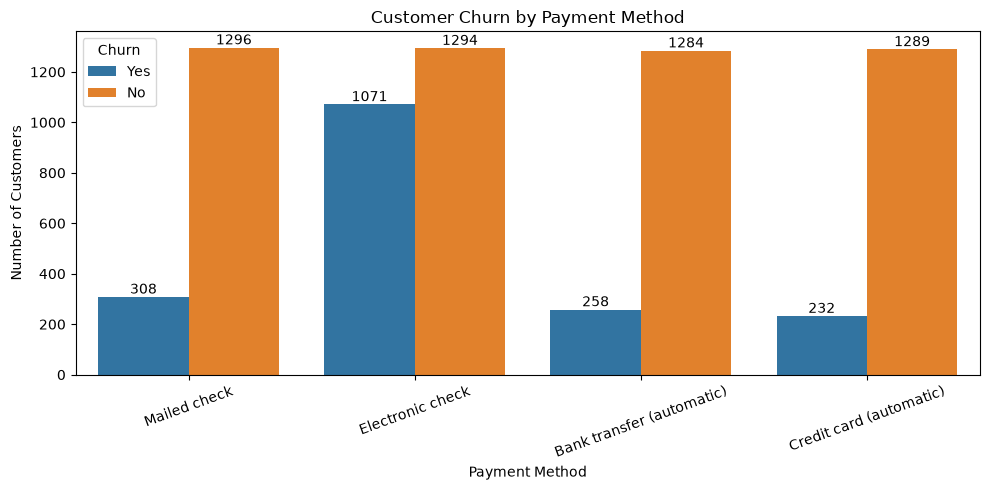

Churn Label                    No     Yes
Payment Method                           
Bank transfer (automatic)  83.27%  16.73%
Credit card (automatic)    84.75%  15.25%
Electronic check           54.71%  45.29%
Mailed check                80.8%   19.2%


In [13]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x="Payment Method",
    hue="Churn Label"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

payment_table = (
    pd.crosstab(
        df["Payment Method"],
        df["Churn Label"],
        normalize="index"
    ) * 100
).round(2)

print(payment_table.astype(str) + "%")

### Analysis

Payment method shows a noticeable relationship with customer churn.

Customers using Electronic Check have the highest churn rate at approximately **45.3%**. In comparison, the churn rates are approximately **19.2%** for Mailed Check, **16.7%** for Bank Transfer (automatic), and **15.3%** for Credit Card (automatic).

This suggests that Electronic Check is associated with considerably higher churn in this dataset and may provide useful information for churn prediction.

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5163.0,61.31,31.09,18.25,25.10,64.45,88.48,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.20,118.35


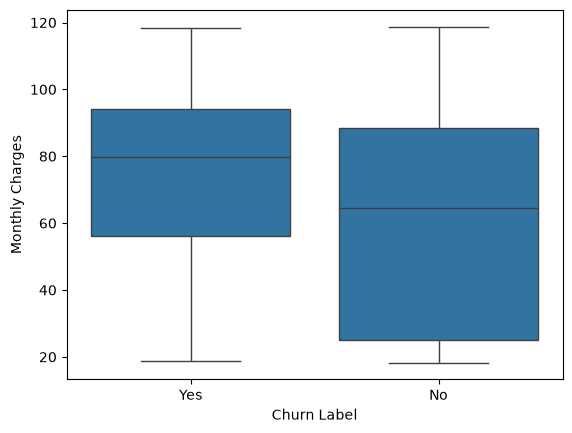

In [14]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)
df.groupby("Churn Label")["Monthly Charges"].describe().round(2)

### Analysis

Customers who churned tend to have higher Monthly Charges than customers who did not churn.

The median Monthly Charges is approximately 80 for churned customers, compared with around 65 for customers who stayed. This suggests that higher monthly charges may be associated with a greater likelihood of churn.

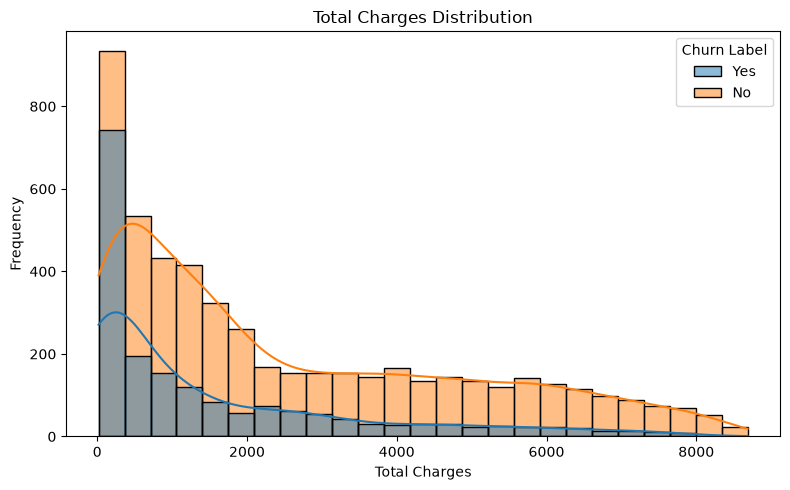

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5163.0,2555.34,2329.46,18.80,577.83,1683.60,4264.12,8672.45
Yes,1869.0,1531.80,1890.82,18.85,134.50,703.55,2331.30,8684.80


In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Total Charges",
    hue="Churn Label",
    kde=True
)

plt.title("Total Charges Distribution")
plt.xlabel("Total Charges")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
df.groupby("Churn Label")["Total Charges"].describe().round(2)

### Analysis

Customers who churned are more concentrated at lower Total Charges values, while customers who did not churn are more widely distributed across higher values.

This may be related to customer tenure, since customers who leave the company earlier have less time to accumulate Total Charges. Therefore, this variable should be interpreted together with tenure and other customer characteristics.

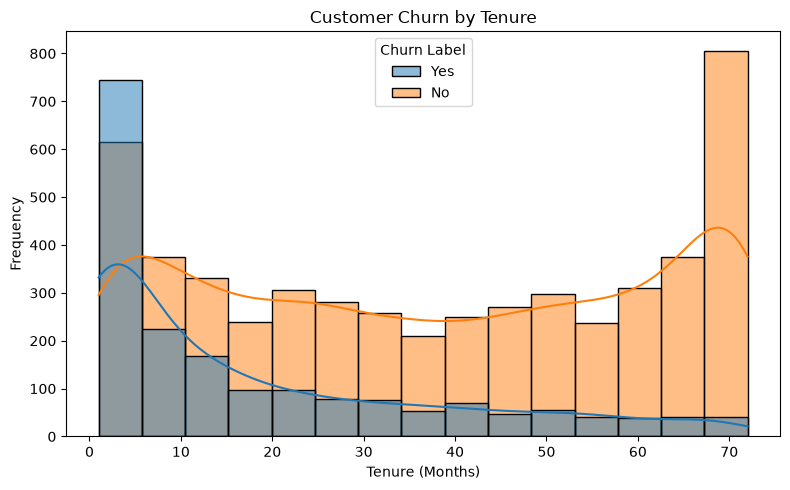

,count,mean,std,min,25%,50%,75%,max
Churn Label,,,,,,,,
No,5163.0,37.65,24.08,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Tenure Months",
    hue="Churn Label",
    kde=True
)

plt.title("Customer Churn by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
df.groupby("Churn Label")["Tenure Months"].describe().round(2)

### Analysis

The distribution shows that churn is more concentrated among customers with shorter tenure. The number of churned customers decreases considerably as tenure increases, while non-churned customers are more evenly distributed and become more prevalent among long-term customers.

This suggests that customers are more likely to churn during the early stages of their relationship with the company, making customer retention during the first months an important area for further analysis.

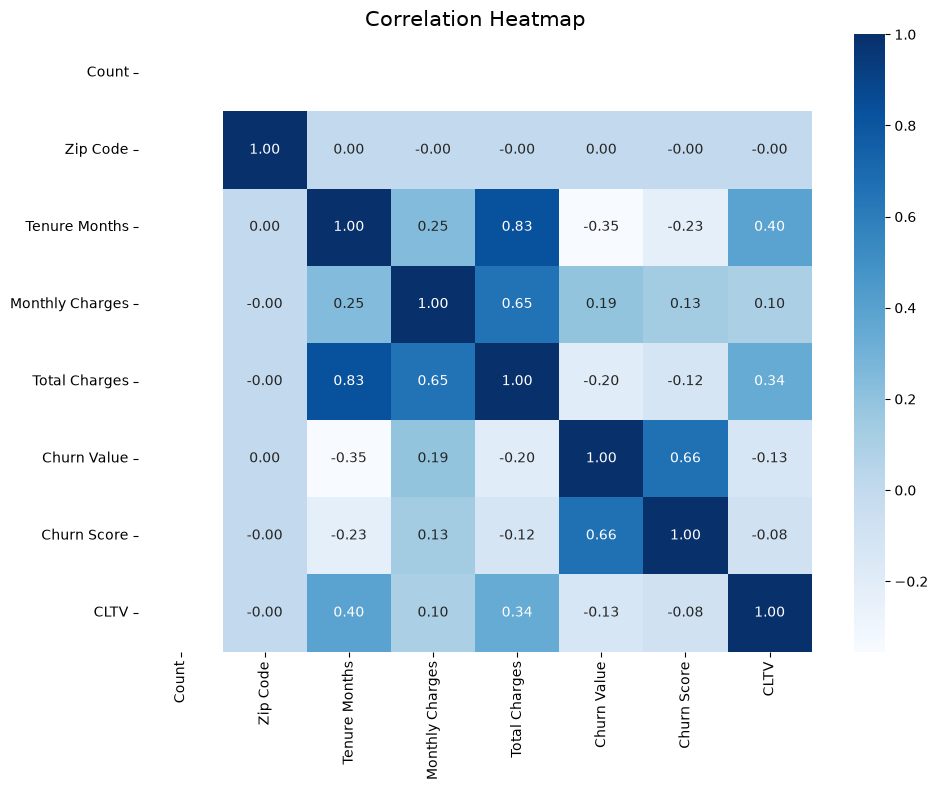

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=["int64","float64"]).corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=15)

plt.tight_layout()
plt.show()

### Analysis

The correlation analysis shows that Tenure Months has a moderate negative correlation with Churn Value (-0.35), suggesting that customers with longer tenure tend to be less likely to churn. Monthly Charges has a weak positive correlation with churn (0.19), while Total Charges has a weak negative correlation (-0.20).

A strong correlation can also be observed between Tenure Months and Total Charges (0.83), as well as between Monthly Charges and Total Charges (0.65). These relationships are expected because total charges are influenced by both the customer's tenure and monthly charges.

The Churn Score also shows a relatively strong correlation with Churn Value (0.66). However, this feature will be excluded from the machine learning stage because it is a derived variable directly related to churn and could introduce data leakage.

## Machine Learning

In this section, a machine learning model is used to predict customer churn based on the characteristics identified during the exploratory analysis.

### Feature Selection

Features that are not useful for prediction or that contain information directly related to the target variable are removed before training the model.

In [18]:
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

df_ml = df.drop(columns=drop_columns)

In [19]:
X = df_ml.drop("Churn Value", axis=1)
y = df_ml["Churn Value"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 19)
Target: (7032,)


### Encoding

In [20]:
X = pd.get_dummies(X, drop_first=True)

print("Features after encoding:", X.shape)

Features after encoding: (7032, 30)


### Train/Test Split

The dataset is divided into training and test sets. The training set is used to train the model, while the test set is kept separate for evaluating its performance on unseen data.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Test Set:", X_test.shape)

Training Set: (5625, 30)
Test Set: (1407, 30)


### Feature Scaling

Numerical features are standardized so that variables with different scales do not disproportionately influence the Logistic Regression model.

In [22]:
numerical_columns = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges"
]

scaler = StandardScaler()

X_train[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

### Class Imbalance

The target variable is imbalanced, with fewer customers classified as churned. SMOTE is applied to the training data to balance the classes before model training.

In [23]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [24]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Churn Value
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:
Churn Value
0    4130
1    4130
Name: count, dtype: int64


### Logistic Regression

Logistic Regression is used as the first baseline classification model for predicting customer churn.

In [25]:

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [26]:
y_pred_lr = log_reg.predict(X_test)

y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

### Model Evaluation

The model is evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [27]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.757640369580668
Precision: 0.5313092979127134
Recall   : 0.7486631016042781
F1 Score : 0.6215316315205327
ROC AUC  : 0.8348522811395085


#### Model Evaluation Analysis

The Logistic Regression model achieved an accuracy of approximately **75.8%**, indicating that it correctly classified around three quarters of the customers in the test set.

However, since the dataset is imbalanced and the main objective is to identify customers at risk of churn, metrics such as recall, F1-score, and ROC-AUC provide a more useful evaluation than accuracy alone.

The model achieved a **recall of 74.9% for churn customers**, meaning that it successfully identified approximately three out of every four customers who actually churned.

The precision for churn predictions was **53.1%**, indicating that slightly more than half of the customers predicted as churn actually left the company. This suggests that the model favors identifying more potential churners at the cost of generating some false positives.

The **F1-score of 62.2%** reflects the balance between precision and recall, while the **ROC-AUC score of 83.5%** indicates that the model has a good ability to distinguish between customers who churn and those who remain.

Overall, the Logistic Regression model provides a useful baseline for churn prediction, particularly due to its relatively high recall.

In [28]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1407
   macro avg       0.71      0.75      0.72      1407
weighted avg       0.80      0.76      0.77      1407



### Confusion Matrix

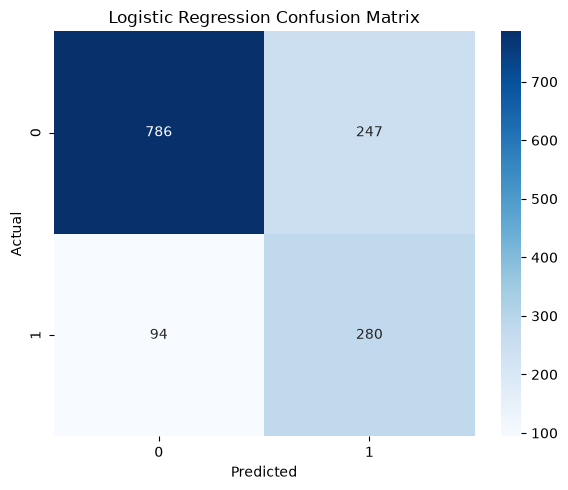

In [29]:
plt.figure(figsize=(6,5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

#### Confusion Matrix Analysis

The confusion matrix provides a more detailed view of the model's predictions.

- **786 customers** were correctly classified as non-churners (True Negatives).
- **280 customers** were correctly identified as churners (True Positives).
- **247 customers** were incorrectly classified as churners (False Positives).
- **94 customers** who actually churned were incorrectly classified as non-churners (False Negatives).

The model successfully identified **280 out of 374 actual churn customers**, which corresponds to a recall of approximately **74.9%**.

From a business perspective, reducing false negatives can be particularly important in churn prediction because these represent customers who are likely to leave but were not identified by the model. The relatively high recall therefore makes the model useful for identifying customers who could be targeted by retention strategies.

### ROC Curve

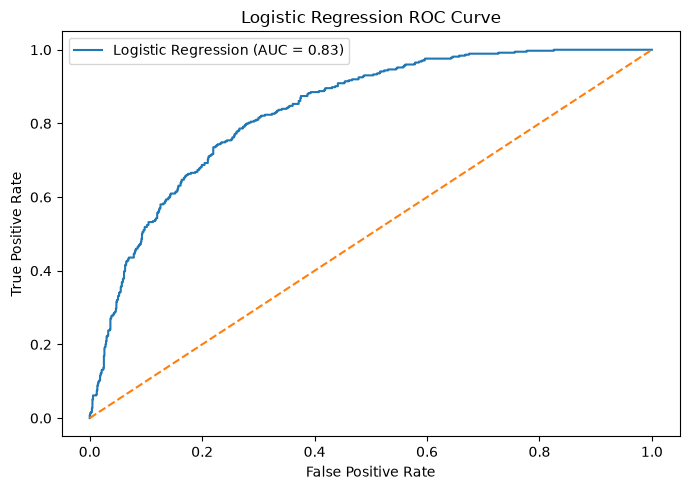

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Logistic Regression ROC Curve")

plt.legend()

plt.tight_layout()
plt.show()

#### ROC Curve Analysis

The ROC curve shows that the Logistic Regression model performs substantially better than random classification across different decision thresholds.

The model achieved a **ROC-AUC score of approximately 0.835**, indicating a good ability to distinguish between customers who churn and customers who remain.

Combined with the recall of approximately **74.9%**, this suggests that the model is reasonably effective at identifying customers at risk of churn while maintaining good overall discriminatory performance.

### Logistic Regression Coefficients

In [31]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})

feature_importance["Absolute Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute Coefficient
1,Monthly Charges,-7.811990,7.811990
10,Internet Service_Fiber optic,7.192079,7.192079
7,Phone Service_Yes,2.880701,2.880701
23,Streaming Movies_Yes,2.796406,2.796406
21,Streaming TV_Yes,2.763973,2.763973
9,Multiple Lines_Yes,1.720947,1.720947
0,Tenure Months,-1.584907,1.584907
6,Dependents_Yes,-1.584743,1.584743
8,Multiple Lines_No phone service,-1.545282,1.545282
17,Device Protection_Yes,1.307559,1.307559


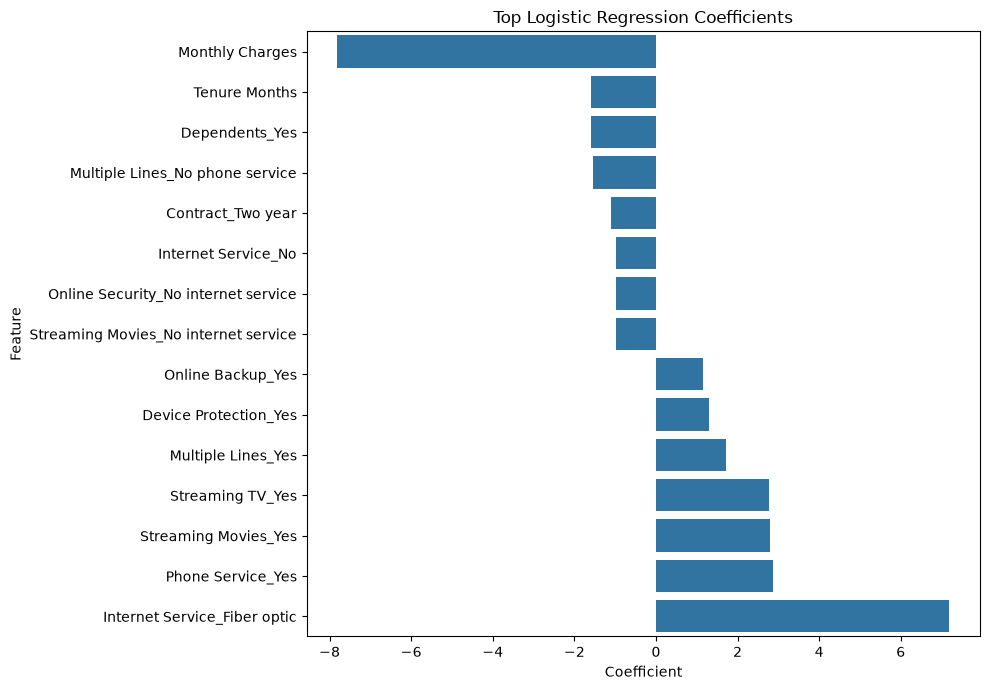

In [32]:
top_features = feature_importance.head(15).sort_values("Coefficient")

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

#### Logistic Regression Coefficient Analysis

The Logistic Regression coefficients provide insight into how different features are associated with the predicted probability of churn while holding the other variables constant.

Some of the model results are consistent with patterns observed during the exploratory analysis. **Tenure Months** and **Two-year contracts** have negative coefficients, supporting the observation that customers with longer relationships and longer-term contracts tend to have a lower risk of churn.

**Fiber optic internet service** has a strong positive coefficient, which is also consistent with the higher churn rate observed among Fiber Optic customers during the exploratory analysis.

However, some coefficients should be interpreted carefully. Several service-related variables are correlated with each other and with Monthly Charges, which can affect both the magnitude and direction of individual Logistic Regression coefficients. For example, although higher Monthly Charges were associated with higher churn during the exploratory analysis, the model assigns a negative coefficient to Monthly Charges when the other customer services are held constant.

Therefore, the coefficients are useful for understanding the model, but they should not be interpreted as direct causal effects or as independent measures of feature importance.

## Conclusion

This project explored customer churn patterns in the IBM Telco Customer Churn dataset and developed a Logistic Regression model to identify customers at risk of leaving the company.

The exploratory analysis revealed several important patterns associated with churn. Customers with **shorter tenure** were more likely to churn, while customers with longer relationships with the company showed greater retention. Contract type also played an important role, with **month-to-month contracts showing substantially higher churn rates**, while one-year and especially two-year contracts were associated with lower churn.

Customers using **Fiber Optic internet service** also showed a higher churn rate compared with other internet service categories. Differences were also observed across payment methods and monthly charges, suggesting that customer service configuration and billing characteristics may contribute to churn behavior.

The Logistic Regression model achieved an **accuracy of approximately 75.8%**, a **recall of 74.9%**, an **F1-score of 62.2%**, and a **ROC-AUC score of approximately 83.5%**. The relatively high recall indicates that the model was able to identify approximately three out of every four customers who actually churned.

The model coefficients also supported several patterns identified during the exploratory analysis. Longer tenure and two-year contracts were associated with lower predicted churn, while Fiber Optic internet service showed a strong positive association with churn. However, some coefficients should be interpreted carefully due to correlations between service-related features.

Overall, the results demonstrate how exploratory data analysis and Machine Learning can be combined to identify customer churn patterns and support customer retention strategies. The Logistic Regression model provides a useful and interpretable baseline that could be further improved through feature engineering, threshold optimization, and comparison with additional classification models.